# Objective 


The primary objective of this Netflix Data Analytics project is to perform an in-depth analysis of the Netflix dataset using Exploratory Data Analysis (EDA) techniques in order to understand content trends, audience preferences, and the overall distribution of movies and TV shows available on the platform. The project aims to transform raw data into meaningful insights that can help identify patterns, relationships, and business opportunities within the entertainment industry.


This project focuses on analyzing various features such as genres, release years, ratings, duration, countries, and content categories to understand how Netflix has evolved over time and how its content strategy has expanded globally. Another important objective is to study the growth of international and multilingual content and evaluate the diversity of entertainment provided to audiences worldwide.
The project also aims to:

: Clean and preprocess the dataset by handling missing values, duplicate records, and inconsistencies.

: Perform descriptive statistical analysis to summarize important characteristics of the dataset.

: Create visualizations to better understand trends, distributions, and patterns in Netflix content.

: Analyze the popularity of different genres and identify the most common types of content available on the platform.

: Study geographical distribution to identify major content-producing countries.

: Examine content ratings and duration patterns to understand audience targeting and viewing preferences.

: Perform time series analysis to identify growth trends in content addition over the years.

: Investigate correlations between different variables such as release year, ratings, and duration.

: Evaluate content variety and audience engagement patterns.

: Draw meaningful conclusions and provide recommendations based on the insights obtained from the analysis.


# Import libraries

In [67]:
import numpy as np

In [68]:
import pandas as pd

In [69]:
import matplotlib as plt
import matplotlib.pyplot as plt


In [70]:
import seaborn as sns

In [71]:
import warnings
warnings.filterwarnings("ignore")
# to keep output clean

# Data Exploration:

In [72]:
df=pd.read_csv(r"/Users/kanha ji/Downloads/netflix_titles.csv")

In [73]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


# Print basic information

In [16]:
df.shape

(8807, 12)

In [17]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [19]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [21]:
# print values_counts for all object_type coloumns with seperators


In [22]:
for i in df.select_dtypes(include=['object']):
    a=df[i].value_counts()
    print(a)

show_id
s1       1
s2       1
s3       1
s4       1
s5       1
        ..
s8803    1
s8804    1
s8805    1
s8806    1
s8807    1
Name: count, Length: 8807, dtype: int64
type
Movie      6131
TV Show    2676
Name: count, dtype: int64
title
Dick Johnson Is Dead     1
Blood & Water            1
Ganglands                1
Jailbirds New Orleans    1
Kota Factory             1
                        ..
Zodiac                   1
Zombie Dumb              1
Zombieland               1
Zoom                     1
Zubaan                   1
Name: count, Length: 8807, dtype: int64
director
Rajiv Chilaka              19
Raúl Campos, Jan Suter     18
Suhas Kadav                16
Marcus Raboy               16
Jay Karas                  14
                           ..
Mu Chu                      1
Chandra Prakash Dwivedi     1
Majid Al Ansari             1
Peter Hewitt                1
Mozez Singh                 1
Name: count, Length: 4528, dtype: int64
cast
David Attenborough                       

# Data Cleaning:



In [28]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [30]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [78]:
df["director"]=df["director"].fillna("No director")
df["cast"]=df["cast"].fillna("No cast")

In [79]:
df

,show_id,type,title,director,cast,country,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,No cast,United States,2020,PG-13,90 min,Documentaries
1,s2,TV Show,Blood & Water,No director,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries"
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
3,s4,TV Show,Jailbirds New Orleans,No director,No cast,NaN,2021,TV-MA,1 Season,"Docuseries, Reality TV"
4,s5,TV Show,Kota Factory,No director,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ..."
...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2007,R,158 min,"Cult Movies, Dramas, Thrillers"
8803,s8804,TV Show,Zombie Dumb,No director,No cast,NaN,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies"
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2009,R,88 min,"Comedies, Horror Movies"
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2006,PG,88 min,"Children & Family Movies, Comedies"


In [62]:
df["country"]=df["country"].fillna("no country")

In [63]:
df


,show_id,type,title,director,cast,country,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,No cast,United States,2020,PG-13,90 min,Documentaries
1,s2,TV Show,Blood & Water,No director,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries"
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",no country,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
3,s4,TV Show,Jailbirds New Orleans,No director,No cast,no country,2021,TV-MA,1 Season,"Docuseries, Reality TV"
4,s5,TV Show,Kota Factory,No director,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ..."
...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2007,R,158 min,"Cult Movies, Dramas, Thrillers"
8803,s8804,TV Show,Zombie Dumb,No director,No cast,no country,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies"
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2009,R,88 min,"Comedies, Horror Movies"
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2006,PG,88 min,"Children & Family Movies, Comedies"


In [64]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
release_year    0
rating          4
duration        3
listed_in       0
dtype: int64

In [74]:
df.drop(['date_added','description'],axis=1 ,inplace = True)

In [53]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
release_year       0
rating             4
duration           3
listed_in          0
dtype: int64

In [54]:
df.head()

,show_id,type,title,director,cast,country,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2020,PG-13,90 min,Documentaries
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries"
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021,TV-MA,1 Season,"Docuseries, Reality TV"
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ..."


In [66]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
release_year    0
rating          4
duration        3
listed_in       0
dtype: int64

In [75]:
df["rating"]=df["rating"].fillna("No rating")


In [80]:
df.isnull().sum()

show_id           0
type              0
title             0
director          0
cast              0
country         831
release_year      0
rating            0
duration          3
listed_in         0
dtype: int64

In [82]:
top_10_country = df['country'].value_counts().head(10)

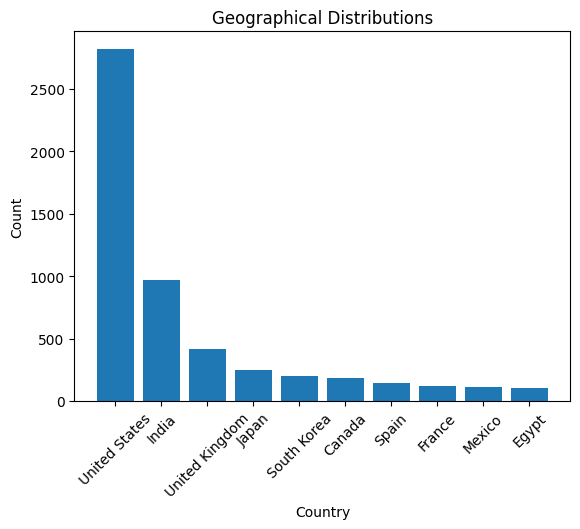

In [83]:
plt.bar(top_10_country.index, top_10_country.values)##.index represents X-axis(countries)and .values represents Y-axis
plt.title("Geographical Distributions")
plt.xticks(rotation=45)
plt.xlabel('Country')
plt.ylabel('Count')
plt.show()

In [84]:
df.head()


,show_id,type,title,director,cast,country,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,No cast,United States,2020,PG-13,90 min,Documentaries
1,s2,TV Show,Blood & Water,No director,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries"
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
3,s4,TV Show,Jailbirds New Orleans,No director,No cast,NaN,2021,TV-MA,1 Season,"Docuseries, Reality TV"
4,s5,TV Show,Kota Factory,No director,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ..."


#  Distribution of content:



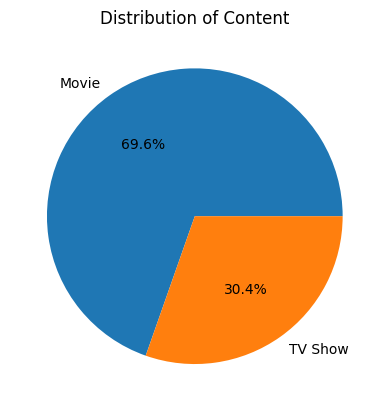

In [85]:
most_used = df['type'].value_counts()
plt.pie(most_used.values, labels=most_used.index, autopct='%1.1f%%')
plt.title('Distribution of Content')
plt.show()

# distribution of  content rating



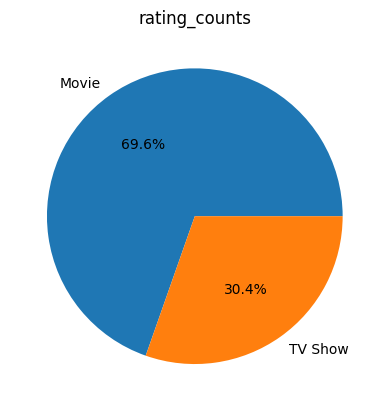

In [97]:
rating_counts = df['type'].value_counts()
plt.pie(rating_counts, labels=most_used.index, autopct='%1.1f%%')
plt.title('rating_counts')
plt.show()

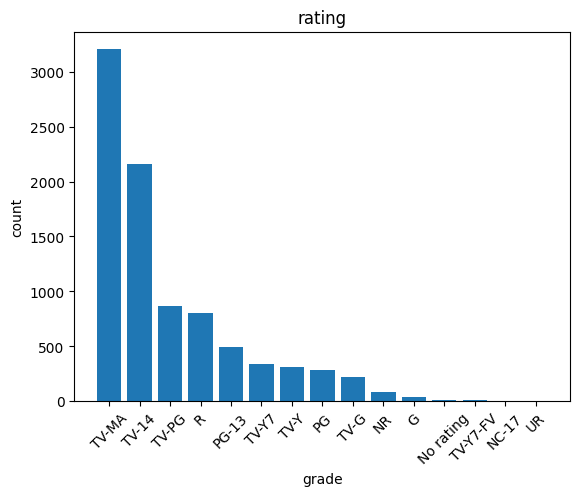

In [102]:
top_10_country = df["rating"].value_counts()
plt.bar(top_10_country.index, top_10_country.values)
plt.title("rating")
plt.xticks(rotation=45)
plt.xlabel("grade")
plt.ylabel("count")
plt.show()

In [96]:
df["rating"] = df["rating"].replace(["74 min","84 min","66 min"],"no rating")

In [103]:
# count of releasing year top 10
# which program type is listed the most 
# distribution of content(type) accross releasing year top=10

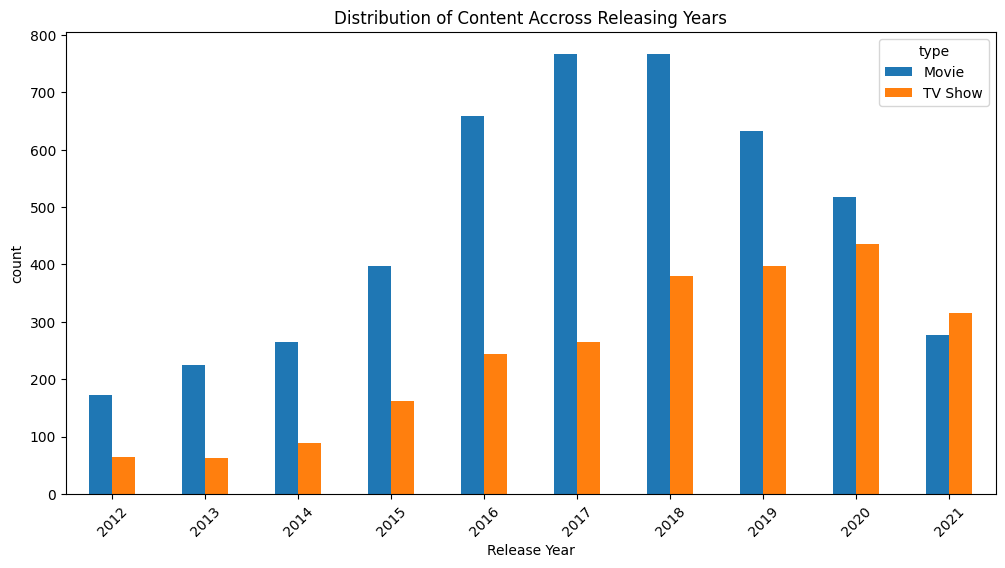

In [104]:
distribution = df.groupby(['release_year','type']).size().unstack()## unstack()="move inner index to coloumns"
 # take last 10 years only
distribution = distribution.tail(10)
distribution.plot(kind='bar',figsize=(12,6))##because your data is 2d(multiple coloumns)
## this graph syntax represents pandas not matplty
plt.title("Distribution of Content Accross Releasing Years")
plt.xticks(rotation=45)
plt.xlabel("Release Year")
plt.ylabel("count")
plt.show()

#  Count of releasing year top 10

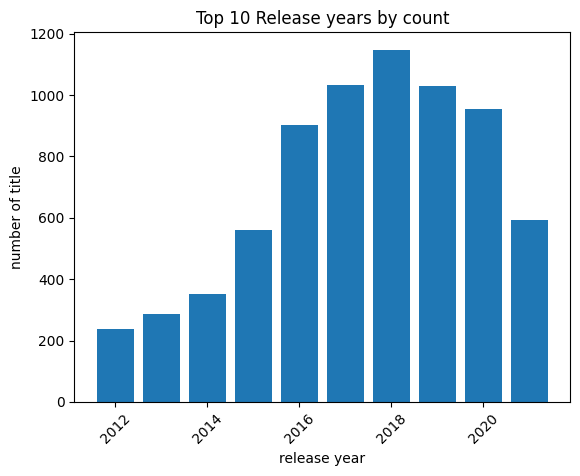

In [105]:
top_10_release_year = df["release_year"].value_counts().head(10)
plt.bar(top_10_release_year.index, top_10_release_year.values)
plt.title("Top 10 Release years by count")
plt.xlabel("release year")
plt.ylabel("number of title")
plt.xticks(rotation=45)
plt.show()

In [106]:
# which program type is listed the most 
most_common_type=df["type"].value_counts()
print("most listed program type:",most_common_type)

most listed program type: type
Movie      6131
TV Show    2676
Name: count, dtype: int64


# Conclusion



This Netflix Data Analytics project provided a comprehensive understanding of the content available on Netflix by applying various Exploratory Data Analysis (EDA) techniques on the dataset. The project successfully analyzed different aspects such as genre distribution, release year trends, geographical contribution, ratings, duration, audience preferences, and overall content growth on the platform.



Through data cleaning and preprocessing, missing values, duplicate records, and inconsistencies were handled effectively to ensure accurate analysis. Multiple visualizations and statistical methods helped uncover meaningful insights from the dataset. The analysis showed that movies dominate Netflix’s content library compared to TV shows, although TV shows continue to gain popularity due to increasing audience engagement and binge-watching trends.


One of the major findings of the project is the rapid growth of Netflix content after 2015, indicating the platform’s aggressive expansion strategy and continuous investment in original productions. The study also revealed that the United States contributes the highest amount of content, while countries like India, South Korea, Canada, and the United Kingdom are becoming important contributors to Netflix’s international growth. This demonstrates Netflix’s focus on expanding regional and multilingual entertainment to attract global audiences.
Genre analysis highlighted that Drama, Comedy, Thriller, and International Movies are among the most popular categories on the platform. Rating analysis further showed that Netflix primarily targets mature and teenage audiences, with TV-MA and TV-14 being the most common content ratings. The duration analysis indicated that most movies follow a standard runtime pattern of approximately 80–120 minutes, suggesting consistency in content production and audience viewing preferences.

